In [6]:
%matplotlib inline

In [7]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

In [8]:
model = load_model(r"C:\Users\yasht\Desktop\CV_FINAL\defect_classifier.h5")

classes = ["inclusion", "rolled_pit", "silk_spot", "waist folding", "crack"]

test_path = test_path = rtest_path = r"C:\Users\yasht\Desktop\dataset\images\images" # you can change

output_path = r"C:\Users\yasht\Desktop\output_results"
os.makedirs(output_path, exist_ok=True)

Processing: crack aug_0_100.jpg
Processing: crack aug_0_1009.jpg
Processing: crack aug_0_1013.jpg
Processing: crack aug_0_1019.jpg
Processing: crack aug_0_1062.jpg
Processing: crack aug_0_11.jpg
Processing: crack aug_0_1115.jpg
Processing: crack aug_0_1135.jpg
Processing: crack aug_0_1149.jpg
Processing: crack aug_0_1166.jpg
Processing: crack aug_0_127.jpg
Processing: crack aug_0_1283.jpg
Processing: crack aug_0_1328.jpg
Processing: crack aug_0_1329.jpg
Processing: crack aug_0_143.jpg
Processing: crack aug_0_1469.jpg
Processing: crack aug_0_148.jpg
Processing: crack aug_0_1486.jpg
Processing: crack aug_0_1503.jpg
Processing: crack aug_0_1512.jpg
Processing: crack aug_0_1611.jpg
Processing: crack aug_0_1667.jpg
Processing: crack aug_0_1675.jpg
Processing: crack aug_0_1690.jpg
Processing: crack aug_0_1701.jpg
Processing: crack aug_0_1702.jpg
Processing: crack aug_0_1723.jpg
Processing: crack aug_0_1748.jpg
Processing: crack aug_0_1768.jpg
Processing: crack aug_0_1778.jpg
Processing: crac

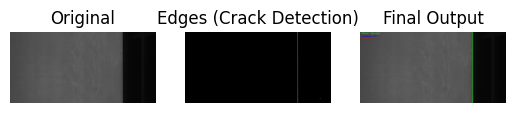

In [9]:
for class_name in os.listdir(test_path):
    class_folder = os.path.join(test_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    for img_name in os.listdir(class_folder):
        print("Processing:", class_name, img_name)

        img_path = os.path.join(class_folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

    # ================= CV PART =================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 30, 100)

    kernel = np.ones((3,3), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)

    # ================= FIND DEFECT REGION =================
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter small noise
min_area = 100  # you can adjust

boxes = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    
    if area > min_area:
        x, y, w, h = cv2.boundingRect(cnt)
        boxes.append((x, y, w, h))

    # ================= ML INPUT =================
    resized = cv2.resize(edges, (128,128))
    input_img = resized.reshape(1,128,128,1) / 255.0

    # ================= PREDICTION =================
    pred = model.predict(input_img)
    class_id = np.argmax(pred)
    label = classes[class_id]
    confidence = np.max(pred)

    # ================= DEFECT % =================
    defect_pixels = np.sum(edges > 0)
    total_pixels = edges.size
    percentage = (defect_pixels / total_pixels) * 100

    # 🔥 Crack override logic (ONLY this inside if)
    if percentage > 8:
        label = "crack"

    # ================= OUTPUT IMAGE =================
    output = img.copy()

    # Draw bounding boxes
for (x, y, w, h) in boxes:
    cv2.rectangle(output, (x, y), (x+w, y+h), (0,255,0), 2)

    cv2.putText(output, f"Defect: {label}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.putText(output, f"Confidence: {confidence:.2f}", (20,80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

    cv2.putText(output, f"Defect %: {percentage:.2f}", (20,120),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

    # ================= SAVE RESULT =================
    save_path = os.path.join(output_path, img_name)
    cv2.imwrite(save_path, output)

    print("Saved at:", save_path)

    # ================= DISPLAY =================
   

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Edges (Crack Detection)")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Final Output")
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()
    plt.pause(0.5)

    input("Press Enter for next image...")

Processing: crack aug_0_100.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_100.jpg


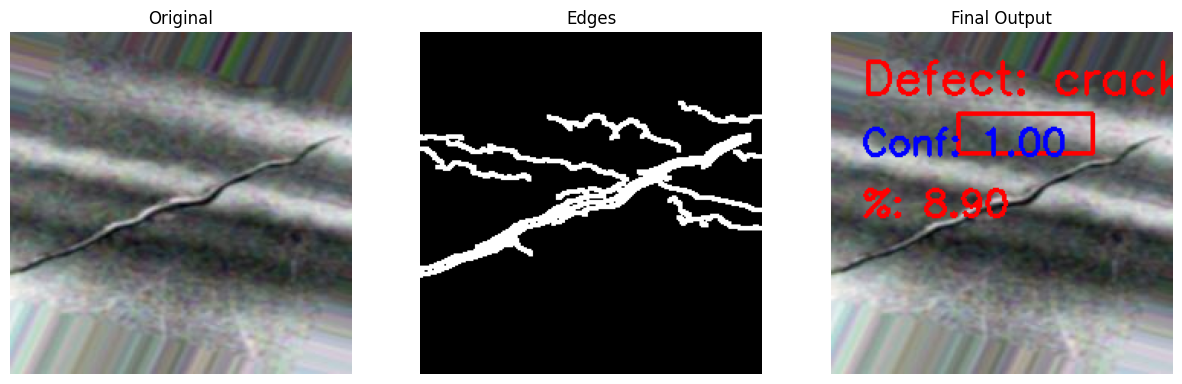

Processing: crack aug_0_1009.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1009.jpg


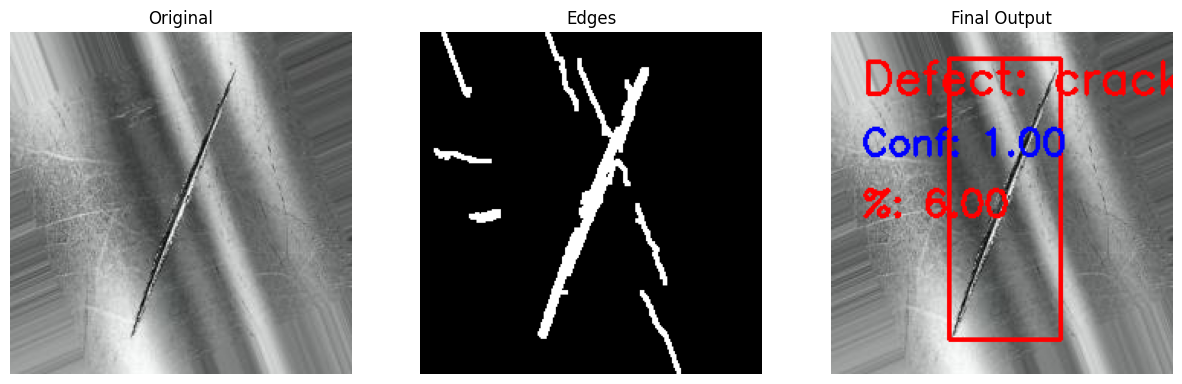

Processing: crack aug_0_1013.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1013.jpg


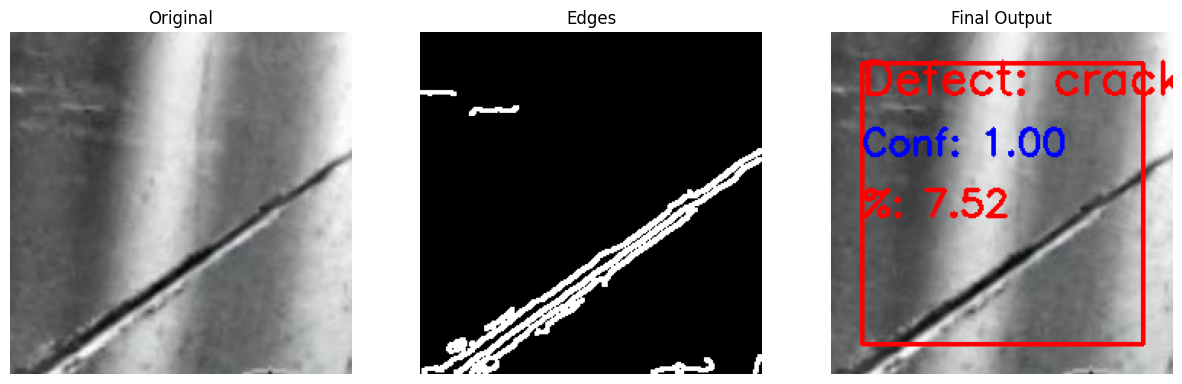

Processing: crack aug_0_1019.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1019.jpg


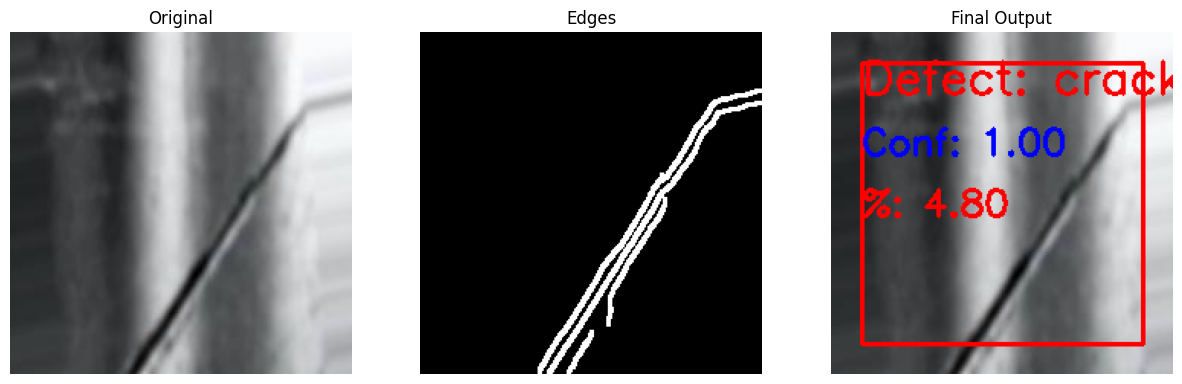

Processing: crack aug_0_1062.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1062.jpg


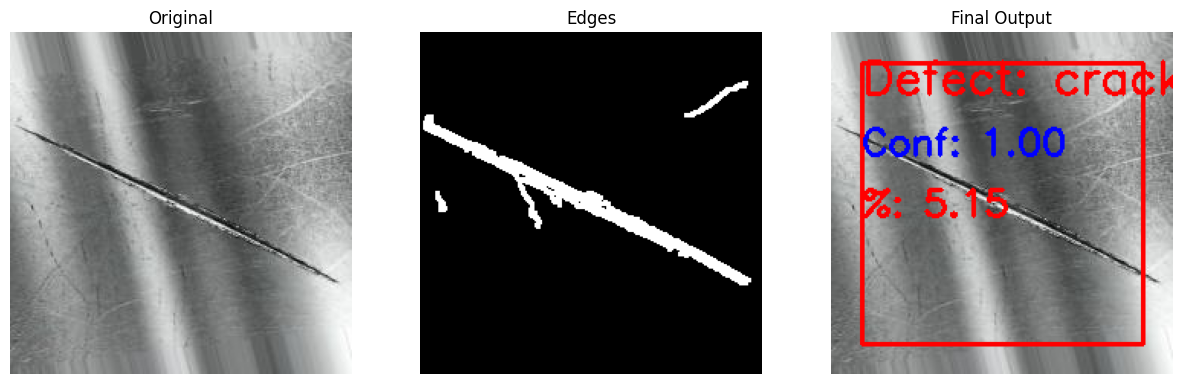

Processing: crack aug_0_11.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_11.jpg
Processing: crack aug_0_1115.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1115.jpg
Processing: crack aug_0_1135.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1135.jpg
Processing: crack aug_0_1149.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1149.jpg
Processing: crack aug_0_1166.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1166.jpg
Processing: crack aug_0_127.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_127.jpg
Processing: crack aug_0_1283.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Saved at: C:\Users\yasht\Desktop\output_results\aug_0_1283.jpg
Processing: crack aug_0_1328.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/st

In [10]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ================= LOAD MODEL =================
model = load_model(r"C:\Users\yasht\Desktop\CV_FINAL\defect_classifier.h5")

classes = ["inclusion", "rolled_pit", "silk_spot", "waist folding", "crack"]

# ================= PATHS =================
test_path = r"C:\Users\yasht\Desktop\dataset\images\images"
output_path = r"C:\Users\yasht\Desktop\output_results"

os.makedirs(output_path, exist_ok=True)

count = 0  # limit display

# ================= MAIN LOOP =================
for class_name in os.listdir(test_path):
    class_folder = os.path.join(test_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    for img_name in os.listdir(class_folder):
        print("Processing:", class_name, img_name)

        img_path = os.path.join(class_folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        # ================= CV PROCESSING =================
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(blur, 50, 150)

        kernel = np.ones((3, 3), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)

        # ================= FIND CONTOURS =================
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        min_area = 200
        boxes = []

        height, width = img.shape[:2]

        for cnt in contours:
            area = cv2.contourArea(cnt)

            if area > min_area:
                x, y, w, h = cv2.boundingRect(cnt)

                # Remove border noise
                if x < 10 or y < 10 or (x + w) > (width - 10) or (y + h) > (height - 10):
                    continue

                # Keep crack-like shapes (long structures)
                if w > 2 * h or h > 2 * w:
                    boxes.append((x, y, w, h))

        # ================= MERGE BOXES =================
        final_box = None

        if boxes:
            x_min = min([b[0] for b in boxes])
            y_min = min([b[1] for b in boxes])
            x_max = max([b[0] + b[2] for b in boxes])
            y_max = max([b[1] + b[3] for b in boxes])

            final_box = (x_min, y_min, x_max, y_max)

        # ================= ML INPUT =================
        resized = cv2.resize(edges, (128, 128))
        input_img = resized.reshape(1, 128, 128, 1) / 255.0

        # ================= PREDICTION =================
        pred = model.predict(input_img)
        class_id = np.argmax(pred)

        label = classes[class_id]
        confidence = np.max(pred)

        # ================= DEFECT % =================
        defect_pixels = np.sum(edges > 0)
        total_pixels = edges.size
        percentage = (defect_pixels / total_pixels) * 100

        # ================= CRACK OVERRIDE =================
        if percentage > 8:
            label = "crack"

        # ================= FALLBACK BOX =================
        if not final_box and label == "crack":
            final_box = (20, 20, width - 20, height - 20)

        # ================= OUTPUT =================
        output = img.copy()

        # Color coding
        if label == "crack":
            color = (0, 0, 255)  # red
        else:
            color = (0, 255, 0)  # green

        # Draw bounding box
        if final_box:
            x1, y1, x2, y2 = final_box
            cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)

        # Add text
        cv2.putText(output, f"Defect: {label}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        cv2.putText(output, f"Conf: {confidence:.2f}", (20, 80),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        cv2.putText(output, f"%: {percentage:.2f}", (20, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

        # ================= SAVE =================
        save_path = os.path.join(output_path, img_name)
        cv2.imwrite(save_path, output)

        print("Saved at:", save_path)

        # ================= DISPLAY =================
        if count < 5:
            plt.figure(figsize=(15, 6))

            plt.subplot(1, 3, 1)
            plt.title("Original")
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Edges")
            plt.imshow(edges, cmap='gray')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Final Output")
            plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
            plt.axis('off')

            plt.show()

            count += 1